### Тензорный считыватель
```pip install numpy```

Для геолина **меняем местами индексы** *суперстроки* и *суперстолбца*:
```[a][b][c][d][e] -> [a][b][d][c][e]```

В классе Tensor это условие учтено, в остальном - нужно следить **самостоятельно**!

In [1]:
import numpy as np
import itertools as it
from math import *
from enum import Enum

class TStatus(Enum):
    EVEN = 0
    VERTICAL = 1
    HORIZONTAL = 2

class Tensor:
    t: list
    dim: int
    covector: int
    vector: int
    deep: int
    status: TStatus
    
    def __init__(self, s, dim: int, covector: int, vector: int, status: TStatus = None, a_type=int):
        # Check dimensions and indexes
        if covector + vector <= 0:
            raise ValueError('ERR: 0 indexes for vectors or covectors')
            
        # Set dimensions
        self.dim = dim
        self.covector, self.vector = covector, vector
        self.deep = covector + vector
        
        # Check status
        if self.deep % 2:
            if status is not None and status != TStatus.EVEN:
                self.status = status
            else:
                self.status = (TStatus.VERTICAL if self.vector == 0 else TStatus.HORIZONTAL)
        else:
            self.status = TStatus.EVEN
        
        if isinstance(s, str):
            # Clear string data
            s = s.replace('−', '-').replace('\u200b', '').split()
            # Empty t
            self.t = np.zeros([self.dim] * self.deep, a_type)
            
            if self.status is TStatus.HORIZONTAL:
                divisors = [ind // 2 + (self.deep // 2 if ind % 2 else 0) for ind in range(self.deep - 1)] + [self.deep - 1]
            else:
                divisors = [ind // 2 + (self.deep // 2 + self.deep % 2 if ind % 2 else 0) for ind in range(self.deep)]
                
            for m in range(len(s)):
                index = [m // (self.dim ** div) % self.dim for div in divisors]
                self.t[*index] = s[m]
                # print(m + 1, '=', ', '.join(str(x + 1) for x in index), '=', s[m])
        elif isinstance(s, (np.ndarray, np.generic)):
            self.t = s
        else:
            self.t = np.zeros([self.dim] * self.deep, a_type)

    def _iterate_show(self):
        """Переборный интератор для show
        ИНДЕКСАЦИЯ: строка - столбец - суперстрока - суперстолбец - гиперстрока - гиперстолбец -
        """
        axes = list(range(self.deep - 1, -1, -1))
        if self.status is TStatus.HORIZONTAL:
            order = [ax for ax in axes if ax % 2 == 0 and ax != axes[0]] + [axes[0]] + [ax for ax in axes if ax % 2 != 0]
        else:
            order = [ax for ax in axes if ax % 2 == 0] + [ax for ax in axes if ax % 2 != 0]
        # print(axes, order)
        for indices in it.product(range(self.dim), repeat=self.deep):
            original_indices = [0] * self.deep
            for original_axis in range(self.deep):
                pos = order.index(original_axis)
                original_indices[original_axis] = indices[pos]
            yield tuple(original_indices)

    
    def show(self, sym_element=' ', sym_line='\n', sym_superline='\n\n', sym_superraw=' | ') -> str:
        """Превращает тензор в текст для вывода:
            sym_element: между двумя элементами, sym_line: перенос каждую строку,
            sym_superline: перенос каждую суперстроку, sym_superraw: перенос каждый суперстолбец.
        
        ИНДЕКСАЦИЯ: строка - столбец - суперстрока - суперстолбец - гиперстрока - гиперстолбец -
        """
        s = ''
        pre_line, pre_superline, pre_superraw = 0, 0, 0
        for indices in self._iterate_show():
            if len(indices) == 1:
                if (pre_line != indices[0]) and (self.status is TStatus.VERTICAL):
                    s += sym_line
                elif indices[0] != 0:
                    s += sym_element
                pre_line = indices[0]
            elif len(indices) == 2:
                if (pre_line != indices[0]):
                    s += sym_line
                elif indices[0] != 0 or indices[1] != 0:
                    s += sym_element
                pre_line = indices[0]
            elif len(indices) == 3:
                if self.status is TStatus.HORIZONTAL:
                    if (pre_line != indices[0]):
                        s += sym_line
                    elif (pre_superraw != indices[2]):
                        s += sym_superraw
                    elif indices[0] != 0 or indices[1] != 0:
                        s += sym_element
                    pre_line, pre_superraw = indices[0], indices[2]
                else:
                    if (pre_line != indices[0]):
                        s += sym_line
                    elif (pre_superline != indices[2]):
                        s += sym_superline
                    elif indices[0] != 0 or indices[1] != 0:
                        s += sym_element
                    pre_line, pre_superline = indices[0], indices[2]
            else:
                if (pre_line != indices[0]):
                    s += sym_line
                elif (pre_superline != indices[2]):
                        s += sym_superline
                elif (pre_superraw != indices[3]):
                    s += sym_superraw
                elif not all(i == 0 for i in indices):
                    s += sym_element
                pre_line, pre_superline, pre_superraw = indices[0], indices[2], indices[3]
            # print(indices)
            s += str(self.t[indices])
        return s
    
    @property
    def format(self):
        return '[' + self.show(', ', '; ', ', ', ', ') +']'
    
    def __getitem__(self, prop):
        return self.t[prop]
    
    def __setitem__(self, key, value):
        self.t[key] = value
    
    def __str__(self):
        return f'Tensor ({self.vector}, {self.covector}), dim = {self.dim}, status = {self.status}\n' + self.show() + '\n' + self.format
    
    def __repr__(self):
        return f'Tensor ({self.vector}, {self.covector})'
    
    def __mul__(self, other):
        return Tensor(other * self.t, self.dim, self.covector, self.vector, self.status)
    
    def __add__(self, other):
        return Tensor(self.t + other.t, self.dim, self.covector, self.vector, self.status)
    
    def __sub__(self, other):
        return Tensor(self.t - other.t, self.dim, self.covector, self.vector, self.status)
    
    @staticmethod
    def fuck_geolin(indices):
        indices = list(indices)
        if len(indices) <= 3:
            return indices
        start = 2  # Начало подсписка для обработки
        if len(indices) % 2:
            # Нечётная длина: обрабатываем элементы со 2 до предпоследнего
            sub_len = len(indices) - 3  # Длина подсписка indices[2:-1]
            processed = [indices[start + i + 1] if i % 2 == 0 else indices[start + i - 1] for i in range(sub_len)]
            return indices[:2] + processed + [indices[-1]]
        else:
            # Чётная длина: обрабатываем все элементы с индекса 2
            sub_len = len(indices) - start
            processed = [indices[start + i + 1] if i % 2 == 0 else indices[start + i - 1] for i in range(sub_len)]
            return indices[:2] + processed
    
    def __matmul__(A, B):
        dim = A.dim
        out = Tensor(0, dim, A.covector + B.covector, A.vector + B.vector, a_type=A.t.dtype)
        for COindicesA in it.product(range(dim), repeat=A.covector):
            for COindicesB in it.product(range(dim), repeat=B.covector):
                for indicesA in it.product(range(dim), repeat=A.vector):
                    for indicesB in it.product(range(dim), repeat=B.vector):
                        indices = Tensor.fuck_geolin(COindicesA + COindicesB + indicesA + indicesB)
                        out[*indices] = A[*(COindicesA+indicesA)] * B[*(COindicesB+indicesB)]     
        return out
        
tens = [
    Tensor('1 2', 2, 1, 0),
    Tensor('1 2', 2, 0, 1),
    Tensor('1 2 3 4', 2, 1, 1),
    Tensor('1 2 3 4 5 6 7 8', 2, 3, 0),
    Tensor('1 2 3 4 5 6 7 8', 2, 0, 3),
    Tensor('1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16', 2, 2, 2),
    Tensor(' '.join(str(x) for x in range(1, 32 + 1)), 2, 5, 0),
    Tensor(' '.join(str(x) for x in range(1, 32 + 1)), 2, 3, 2)
]
# [print('========== ', ten.status, '\n', ten, sep='') for ten in tens[:]]
    

### Задача 8

In [2]:
# СЕМЁН

A = Tensor('1 3 -4 -3', 2, 0, 2)
B = Tensor('-3 -6', 2, 0, 1)
C = Tensor('3 2', 2, 1, 0)
D = Tensor('0 -6', 2, 1, 0)
E = Tensor('3 -3', 2, 0, 1)
# print(A, B, C, D, E, sep='\n===\n')

R = A @ (((B * -5) @ C) + ((D * 3) @ E))
print(R.format)

[45, 135, -180, -135; -24, -72, 96, 72; 90, 270, -360, -270; 114, 342, -456, -342]


### Задача 10

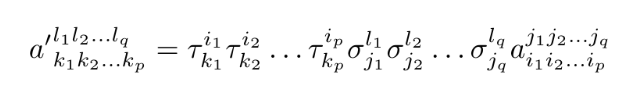

Для этого случая немая сумма будет такая
$\tilde{a}^{j}_{mt} = \tau^{i_1}_{m} * \tau^{i_2}_{t} * \sigma^{j}_{j_1} * a^{j_1}_{i_1 i_2}$

In [3]:
data = "2 8 −7 ​ 4 5 −3 ​ −4 −1 −6 ​ −5 −5 −2 ​ 5 5 6 ​ −3 7 −2 ​ −8 −6 −3 ​ 7 4 −7 ​ 1 −2 −1 ​ ​​​"
a = Tensor(data, 3, 1, 2)
print(a)

e1, e2, e3 = [-1, 1, 0], [2, -1, -1], [1, -2, 2]
old_basis = np.matrix([[e1[0], e2[0], e3[0]], [e1[1], e2[1], e3[1]], [e1[2], e2[2], e3[2]]], float)
e1, e2, e3 = [1, 2, 1], [1, 3, 2], [-2, -6, -3]
new_basis = np.matrix([[e1[0], e2[0], e3[0]], [e1[1], e2[1], e3[1]], [e1[2], e2[2], e3[2]]], float)
# print(old_basis, new_basis, sep='\n')

S = np.linalg.inv(new_basis).dot(old_basis)
T = np.around(np.linalg.inv(S), 12)
T, S = np.asarray(T), np.asarray(S)
print(T, S, sep='\n')

tilde_a = np.zeros((3, 3, 3))
for (j, m, t) in it.product(range(3), repeat=3):
    total = 0
    for (i1, i2, j1) in it.product(range(3), repeat=3):
            total += T[i1, m] * T[i2, t] * S[j, j1] * a[j1, i1, i2]
    tilde_a[j, m, t] = total

tilde_a = np.round(tilde_a, 10).astype(int)
res_tensor = Tensor(tilde_a, 3, 1, 2)
print(res_tensor)

Tensor (2, 1), dim = 3, status = TStatus.HORIZONTAL
2 4 -4 | -5 5 -3 | -8 7 1
8 5 -1 | -5 5 7 | -6 4 -2
-7 -3 -6 | -2 6 -2 | -3 -7 -1
[2, 4, -4, -5, 5, -3, -8, 7, 1; 8, 5, -1, -5, 5, 7, -6, 4, -2; -7, -3, -6, -2, 6, -2, -3, -7, -1]
[[ 17.  25. -47.]
 [  7.  10. -19.]
 [  4.   6. -11.]]
[[-4.  7.  5.]
 [-1. -1.  6.]
 [-2.  2.  5.]]
Tensor (2, 1), dim = 3, status = TStatus.HORIZONTAL
415 528 -1067 | 493 607 -1252 | -1159 -1479 2988
-21597 -31694 59498 | -31839 -46720 87710 | 59712 87626 -164500
-11338 -16667 31262 | -16758 -24631 46202 | 31344 46074 -86421
[415, 528, -1067, 493, 607, -1252, -1159, -1479, 2988; -21597, -31694, 59498, -31839, -46720, 87710, 59712, 87626, -164500; -11338, -16667, 31262, -16758, -24631, 46202, 31344, 46074, -86421]
